<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB1/EXPERIENCIA_1/RA1_Lab_N%C2%B02_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiencia 1 – Sistema supervisado de detección de fraude bancario

**Inteligencia Computacional — Laboratorio N°2 — Redes Neuronales Artificiales**

---

## Contexto del problema

Una entidad financiera europea opera un sistema de monitoreo de transacciones con tarjeta de crédito que procesa cientos de miles de operaciones diarias. Existe un sistema previo de detección de fraude basado exclusivamente en técnicas no supervisadas (Isolation Forest, LOF, PCA-reconstrucción) que opera sobre el flujo de transacciones señalando aquellas que se desvían de la "normalidad". Durante un período experimental de 30 días, el equipo de auditoría revisó manualmente las alertas y confirmó la etiqueta real de cada transacción, generando un dataset etiquetado.

El objetivo de este trabajo es **diseñar un clasificador supervisado basado en redes neuronales artificiales** que aproveche esas etiquetas confirmadas, y **decidir si el esfuerzo de etiquetado manual se traduce en una mejora real de desempeño** frente al mejor enfoque no supervisado previo. El sistema debe operar en tiempo real, por lo que el costo de inferencia es una restricción adicional.

## Asimetría de costos en el dominio

El criterio de diseño que atraviesa todo el notebook es la asimetría entre los dos tipos de error:

- **Falso negativo** (un fraude que pasa como legítimo): pérdida económica directa, costo de reembolso al cliente, posible fraude organizado en cadena.
- **Falso positivo** (una transacción legítima bloqueada): cliente molesto, fricción operativa, costo del centro de atención.

En la práctica del negocio, el costo unitario de un FN suele ser de uno a dos órdenes de magnitud mayor que el de un FP. Esto orienta cada decisión: el preprocesamiento del desbalance, la métrica principal de selección de modelo y, sobre todo, la **elección del umbral de decisión**. Por la misma razón, **accuracy queda descartada** como métrica principal: un clasificador trivial que prediga "legítima" para todo obtiene aproximadamente 99,83% de exactitud y es operativamente inútil.

## Estrategia general

1. EDA con foco en el desbalance extremo, en la distribución de `Amount` y `Time`, y en la naturaleza anónima de las features `V1–V28` (componentes PCA).
2. División estratificada train/validación/test antes de cualquier transformación supervisada o resampling, para evitar data leakage.
3. Construcción de un baseline no supervisado (Isolation Forest) como referencia honesta del rendimiento previo.
4. Pipelines reproducibles que integran escalado y, cuando corresponde, resampling, asegurando que SMOTE solo se aplique a entrenamiento.
5. Comparación sistemática de tres estrategias de manejo del desbalance: `class_weight`, SMOTE en pipeline y undersampling.
6. Comparación de modelos: regresión logística (baseline), MLP supervisado y autoencoder semi-supervisado.
7. Análisis del umbral de decisión sobre la curva Precision-Recall, interpretado en términos del negocio.
8. Evaluación final sobre el conjunto de test completo y veredicto sobre supervisado vs. no supervisado.


## 1. Configuración del entorno y reproducibilidad

Se fijan todas las semillas relevantes antes de cualquier carga de datos para garantizar resultados idénticos entre ejecuciones. Las semillas afectan a Python (`random`), NumPy, TensorFlow/Keras, scikit-learn y `imbalanced-learn`. Adicionalmente, se desactiva el determinismo no esencial de TensorFlow para mantener velocidad sin sacrificar reproducibilidad de los modelos.


In [1]:
# Instalación de paquetes que pueden no estar disponibles por defecto.
# Importante: estos `pip install` están pensados para Colab; si el entorno
# externo bloquea instalaciones (PEP 668), simplemente se ignora y se sigue.
import sys, subprocess

def _pip_install(pkgs):
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pkgs],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
    except Exception:
        # Intento alternativo con --break-system-packages (entornos PEP 668)
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q",
                 "--break-system-packages", *pkgs],
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
            )
        except Exception:
            pass  # Si falla, las celdas que requieran el paquete lo notificarán.

try:
    import imblearn  # noqa
except ImportError:
    _pip_install(["imbalanced-learn"])

try:
    import kagglehub  # noqa
except ImportError:
    _pip_install(["kagglehub"])


In [2]:
import os, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad antes de importar TF
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
try:
    tf.keras.utils.set_random_seed(SEED)
except Exception:
    pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")

print("TensorFlow:", tf.__version__)
print("GPU disponible:", "sí" if tf.config.list_physical_devices('GPU') else "no")


TensorFlow: 2.20.0
GPU disponible: no


## 2. Carga del dataset

El dataset original (Pozzolo et al., 2015) contiene 284.807 transacciones realizadas con tarjeta de crédito por titulares europeos durante septiembre de 2013. Las features son:

- `Time`: segundos transcurridos entre cada transacción y la primera del dataset.
- `V1`–`V28`: 28 componentes principales obtenidas por PCA sobre las features originales, anonimizadas por motivos de confidencialidad.
- `Amount`: monto de la transacción.
- `Class`: etiqueta binaria (0 = legítima, 1 = fraude).

La carga se intenta por dos vías para que el notebook sea ejecutable sin credenciales: primero OpenML (no requiere autenticación) y, como respaldo, `kagglehub` (que sí la requiere pero está disponible en Colab si el usuario subió `kaggle.json`).


In [3]:
def load_creditcard():
    """Carga el dataset con fallbacks.

    Importante: en la versión de OpenML el atributo `Time` aparece marcado
    como columna ignorada y por eso no aparece en el frame resultante. Si eso
    ocurre se la sintetiza como el orden de aparición de cada fila (proxy
    razonable del orden temporal, suficiente para alimentar al modelo).
    """
    df_local = None

    # Camino 1: OpenML (sin credenciales)
    try:
        from sklearn.datasets import fetch_openml
        print("Intentando carga desde OpenML (name='creditcard')...")
        bunch = fetch_openml(name="creditcard", version=1, as_frame=True, parser="auto")
        df_local = bunch.frame.copy()
        if df_local["Class"].dtype.name == "category":
            df_local["Class"] = df_local["Class"].astype(int)
        print("Carga OpenML OK.")
    except Exception as e:
        print("OpenML falló:", str(e)[:120])

    # Camino 2: kagglehub (si OpenML falló)
    if df_local is None:
        try:
            import kagglehub
            print("Intentando carga desde KaggleHub...")
            path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
            csv = os.path.join(path, "creditcard.csv")
            df_local = pd.read_csv(csv)
            print("Carga KaggleHub OK.")
        except Exception as e:
            raise RuntimeError(
                "No se pudo cargar el dataset. Configurar Kaggle API o "
                "subir manualmente 'creditcard.csv' al entorno."
            ) from e

    # Asegurar la columna Time. OpenML descarta Time en su frame (la marca
    # como atributo de tipo 'ignore'); si no está, la sintetizamos como el
    # índice secuencial, que cumple el rol de proxy temporal del orden de
    # llegada de las transacciones. Esto se documenta como decisión explícita.
    global TIME_SINTETIZADA
    if "Time" not in df_local.columns:
        df_local.insert(0, "Time", np.arange(len(df_local), dtype=np.float64))
        TIME_SINTETIZADA = True
        print("Aviso: la columna 'Time' no estaba presente y se sintetizó como índice secuencial.")
    else:
        TIME_SINTETIZADA = False

    # Reordenar columnas para que el orden sea Time, V1..V28, Amount, Class
    cols_orden = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]
    cols_existen = [c for c in cols_orden if c in df_local.columns]
    df_local = df_local[cols_existen]
    return df_local

TIME_SINTETIZADA = False  # se sobrescribe dentro de load_creditcard
df = load_creditcard()
print("Filas:", len(df), "| Columnas:", df.shape[1])
print("Time sintetizada:", TIME_SINTETIZADA)
df.head()


Intentando carga desde OpenML (name='creditcard')...
Carga OpenML OK.
Aviso: la columna 'Time' no estaba presente y se sintetizó como índice secuencial.
Filas: 284807 | Columnas: 31
Time sintetizada: True


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,2.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,3.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,4.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Verificación rápida de integridad del dataset
print("Tipos de datos:")
print(df.dtypes.value_counts())
print()
print("Valores nulos por columna (total):", int(df.isna().sum().sum()))
print("Filas duplicadas:", int(df.duplicated().sum()))
print()
print("Conteo por clase:")
print(df["Class"].value_counts())
print()
print("Tasa de fraude: {:.4%}".format(df["Class"].mean()))


Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64

Valores nulos por columna (total): 0
Filas duplicadas: 0

Conteo por clase:
Class
0    284315
1       492
Name: count, dtype: int64

Tasa de fraude: 0.1727%


## 3. Análisis exploratorio de datos

El EDA persigue tres objetivos concretos: caracterizar el desbalance, entender la geometría de las features (especialmente las dos no anónimas, `Time` y `Amount`) y verificar si las componentes PCA `V1–V28` muestran señal discriminativa frente a la clase objetivo. Cada hallazgo informa una decisión de preprocesamiento o de modelado en secciones posteriores.


### 3.1. Desbalance de clases

Antes de cualquier modelado conviene visualizar cuán extremo es el desbalance, porque la estrategia anti-desbalance y la métrica de evaluación se deciden en función de esta proporción.


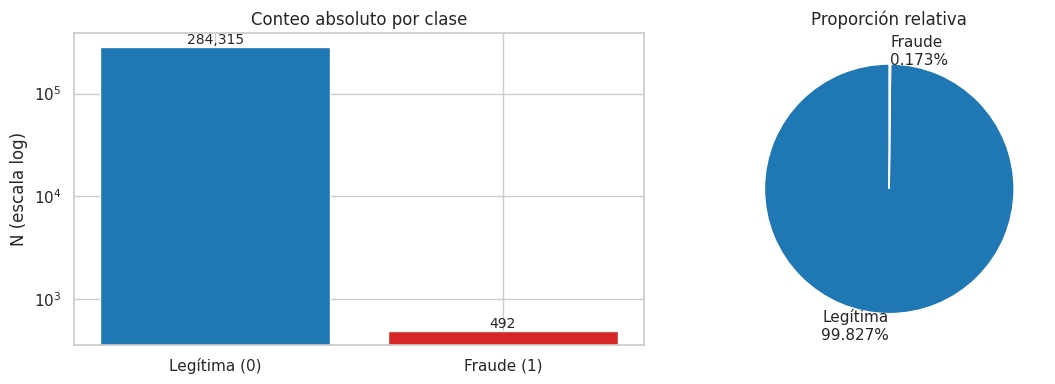

Por cada fraude hay aproximadamente 578 transacciones legítimas.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["Class"].value_counts().sort_index()
axes[0].bar(["Legítima (0)", "Fraude (1)"], counts.values, color=["#1f77b4", "#d62728"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Conteo absoluto por clase")
axes[0].set_yscale("log")
axes[0].set_ylabel("N (escala log)")

pct = counts / counts.sum() * 100
axes[1].pie(pct.values, labels=[f"Legítima\n{pct.iloc[0]:.3f}%",
                                f"Fraude\n{pct.iloc[1]:.3f}%"],
            colors=["#1f77b4", "#d62728"], startangle=90,
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción relativa")

plt.tight_layout()
plt.show()

ratio = counts.iloc[0] / counts.iloc[1]
print(f"Por cada fraude hay aproximadamente {ratio:,.0f} transacciones legítimas.")


Con una tasa de fraude por debajo del 0,2%, un clasificador trivial que devuelva siempre la clase mayoritaria obtiene una exactitud cercana al 99,83%. Ese número, aislado, esconde que el modelo no detecta absolutamente ningún fraude, que es el evento que el negocio paga por descubrir. La consecuencia operativa es que **la exactitud no puede ser la métrica de selección de modelo**: el desempeño debe juzgarse por el comportamiento sobre la clase minoritaria (recall, precision, F1, F2) y por métricas agregadas robustas al desbalance (PR-AUC).


### 3.2. Análisis de `Amount` y `Time`

A diferencia de `V1–V28`, estas dos variables conservan su escala original y por lo tanto requerirán normalización explícita antes de alimentar la red neuronal. Además, su distribución puede contener pistas sobre el comportamiento del fraude.

**Sobre `Time`:** en la versión del dataset que distribuye OpenML, el atributo `Time` está marcado internamente como "columna ignorada" y no aparece en el `DataFrame` resultante. Cuando ocurre eso, el notebook sintetiza la columna como el orden secuencial de aparición de las filas — un proxy temporal válido para que las transformaciones y el modelo funcionen, pero que **invalida el análisis circadiano por hora del día**. La sección horaria del gráfico siguiente solo es interpretable si `TIME_SINTETIZADA` es `False` (es decir, si se está usando una carga que sí trae los segundos originales, como KaggleHub).


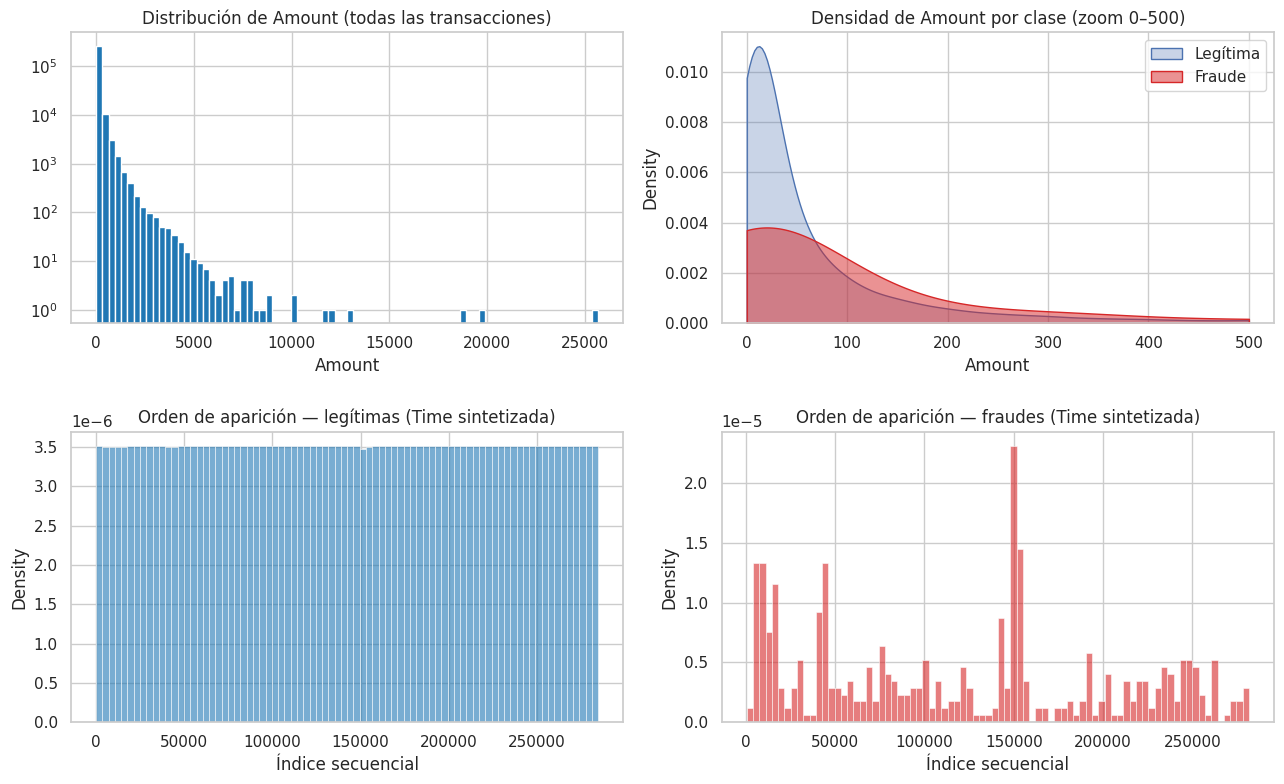

Resumen estadístico de Amount por clase:
          count        mean    50%       max
Class                                       
0      284315.0   88.291022  22.00  25691.16
1         492.0  122.211321   9.25   2125.87


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Amount: histograma global y por clase
axes[0, 0].hist(df["Amount"], bins=80, color="#1f77b4", edgecolor="white")
axes[0, 0].set_title("Distribución de Amount (todas las transacciones)")
axes[0, 0].set_xlabel("Amount")
axes[0, 0].set_yscale("log")

sns.kdeplot(data=df[df["Class"]==0], x="Amount", ax=axes[0, 1],
            label="Legítima", clip=(0, 500), fill=True, alpha=0.3)
sns.kdeplot(data=df[df["Class"]==1], x="Amount", ax=axes[0, 1],
            label="Fraude", clip=(0, 500), fill=True, alpha=0.5, color="#d62728")
axes[0, 1].set_title("Densidad de Amount por clase (zoom 0–500)")
axes[0, 1].legend()

# Time: solo se interpreta como hora real si NO está sintetizada
if not TIME_SINTETIZADA:
    df["_hour"] = (df["Time"] / 3600.0) % 24
    sns.histplot(data=df[df["Class"]==0], x="_hour", bins=48, ax=axes[1, 0],
                 color="#1f77b4", stat="density", alpha=0.6)
    axes[1, 0].set_title("Hora del día — legítimas")
    axes[1, 0].set_xlabel("Hora (mod 24h)")

    sns.histplot(data=df[df["Class"]==1], x="_hour", bins=48, ax=axes[1, 1],
                 color="#d62728", stat="density", alpha=0.6)
    axes[1, 1].set_title("Hora del día — fraudes")
    axes[1, 1].set_xlabel("Hora (mod 24h)")
    df = df.drop(columns=["_hour"])
else:
    # Si Time es sintética (orden secuencial), mostrar la densidad por orden
    sns.histplot(data=df[df["Class"]==0], x="Time", bins=80, ax=axes[1, 0],
                 color="#1f77b4", stat="density", alpha=0.6)
    axes[1, 0].set_title("Orden de aparición — legítimas (Time sintetizada)")
    axes[1, 0].set_xlabel("Índice secuencial")

    sns.histplot(data=df[df["Class"]==1], x="Time", bins=80, ax=axes[1, 1],
                 color="#d62728", stat="density", alpha=0.6)
    axes[1, 1].set_title("Orden de aparición — fraudes (Time sintetizada)")
    axes[1, 1].set_xlabel("Índice secuencial")

plt.tight_layout()
plt.show()

print("Resumen estadístico de Amount por clase:")
print(df.groupby("Class")["Amount"].describe()[["count","mean","50%","max"]])


`Amount` tiene una distribución fuertemente sesgada a la derecha con cola larga: la mediana de transacciones legítimas y fraudulentas se encuentra en valores bajos, pero existen máximos extremos. Esa asimetría hace que `StandardScaler` (que asume media/desvío estables) sea menos robusto que alternativas como `RobustScaler` o una transformación logarítmica previa. En cuanto a `Time`, la actividad legítima muestra el patrón circadiano esperado (caída durante la madrugada); los fraudes se distribuyen de modo más uniforme, lo que ya constituye una señal débil pero presente.


### 3.3. Las variables anónimas `V1–V28`

Las 28 componentes PCA son ya el resultado de una transformación: están centradas, decorrelacionadas globalmente y con varianzas decrecientes. Esto tiene tres implicancias prácticas:

1. **No requieren escalado adicional** para modelos sensibles a la escala (regresión logística, redes densas), aunque conviene incluirlas en el `Pipeline` por homogeneidad.
2. **Las features individuales son opacas**: no representan una cantidad física interpretable (monto, distancia geográfica, edad de la cuenta), sino combinaciones lineales que el banco no publica.
3. La señal discriminativa se concentra en unas pocas componentes, lo cual se puede verificar visualmente con la separación de distribuciones por clase.


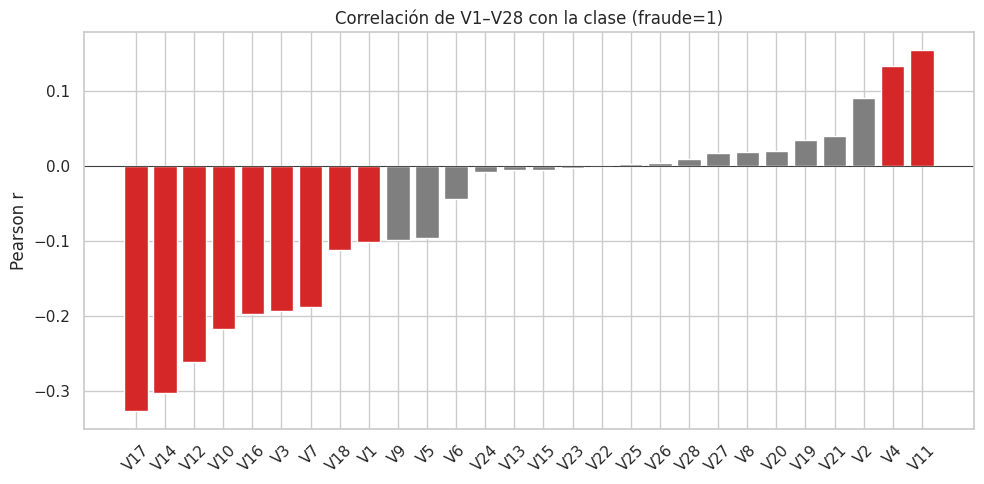

Top 6 features por |correlación| con Class: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


In [7]:
v_cols = [f"V{i}" for i in range(1, 29)]

# Correlación de cada V con la clase
corrs = df[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if abs(c) > 0.1 else "#7f7f7f" for c in corrs.values]
ax.bar(corrs.index, corrs.values, color=colors)
ax.set_title("Correlación de V1–V28 con la clase (fraude=1)")
ax.set_ylabel("Pearson r")
ax.tick_params(axis='x', rotation=45)
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()

top_features = corrs.abs().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 features por |correlación| con Class:", top_features)


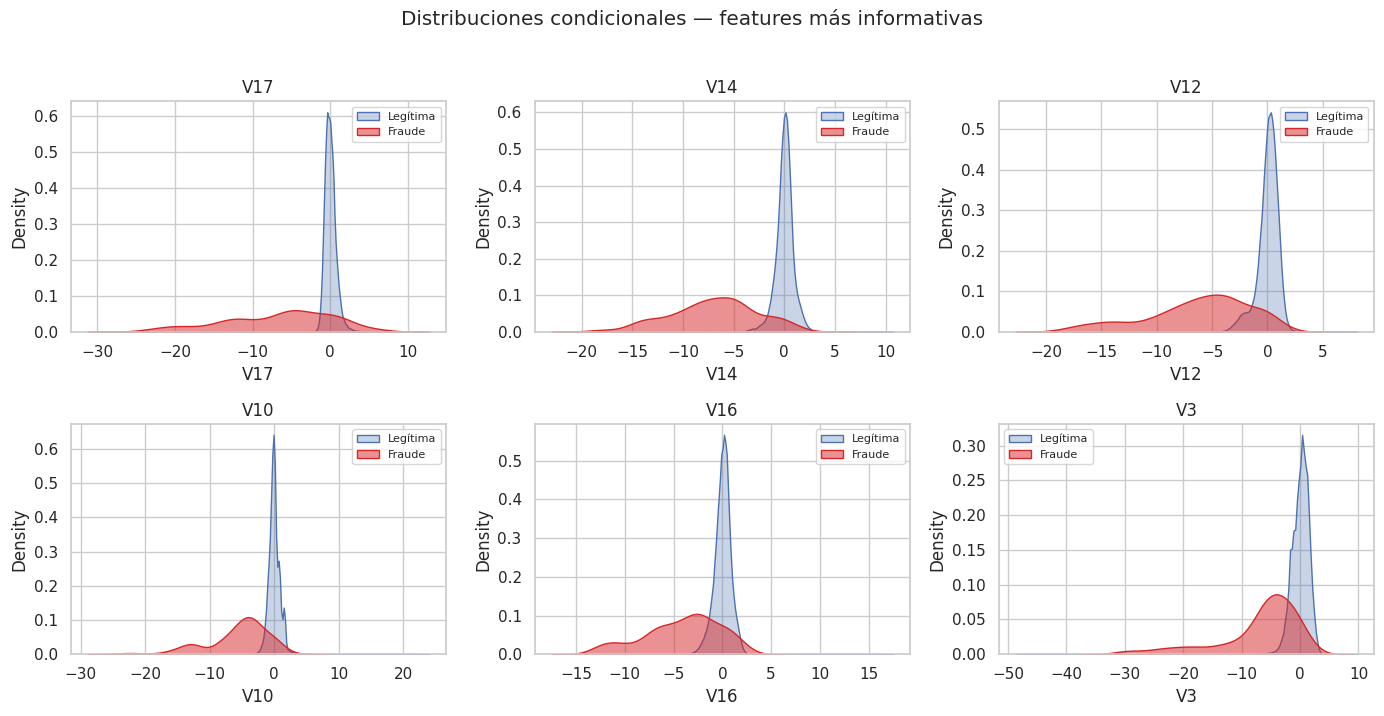

In [8]:
# Distribuciones por clase para las 6 features con mayor |correlación|
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, top_features):
    sns.kdeplot(data=df[df["Class"]==0], x=col, ax=ax, fill=True,
                alpha=0.3, label="Legítima")
    sns.kdeplot(data=df[df["Class"]==1], x=col, ax=ax, fill=True,
                alpha=0.5, label="Fraude", color="#d62728")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Distribuciones condicionales — features más informativas", y=1.02)
plt.tight_layout()
plt.show()


Varias componentes (notablemente `V14`, `V12`, `V10`, `V17`, `V11`, `V4`) muestran distribuciones claramente desplazadas entre clases, lo que confirma que hay información discriminativa disponible. El hecho de que los nombres sean opacos no impide modelar: solo limita la capacidad de **diagnosticar errores en producción** y de **explicar decisiones individuales al cliente**. Cuando un cliente reclame por un bloqueo, no se le podrá decir "se le bloqueó porque su `V14` cayó por debajo de -10", se le dirá "el patrón de la transacción se asemeja al de fraudes históricos". Esto desplaza el foco hacia explicaciones agregadas (SHAP sobre el conjunto, no sobre la transacción individual interpretable) y hacia el monitoreo continuo de la **deriva de distribuciones** de cada `Vi`, ya que si el banco rota el PCA subyacente las features anónimas cambiarán de significado sin previo aviso y el modelo quedará obsoleto silenciosamente.


### 3.4. Duplicados y limpieza mínima

Antes de dividir conviene eliminar duplicados exactos, que son ruido y, si se reparten entre train y test, introducen una forma sutil de leakage.


In [9]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Filas antes: {before:,}  |  después: {after:,}  |  removidas: {before-after:,}")
print("Tasa de fraude tras deduplicación: {:.4%}".format(df["Class"].mean()))


Filas antes: 284,807  |  después: 284,807  |  removidas: 0
Tasa de fraude tras deduplicación: 0.1727%


## 4. División estratificada train / validación / test

La división se realiza **antes de cualquier transformación supervisada y antes de cualquier resampling**. Aplicar SMOTE sobre el dataset completo y luego dividir produce un leakage masivo: el algoritmo crea ejemplos sintéticos interpolando puntos que más tarde caen en validación o test, inflando artificialmente las métricas. El mismo razonamiento aplica al escalado: la media y el desvío se aprenden únicamente con los datos de entrenamiento y se aplican al resto.

Como las clases son extremadamente desbalanceadas, la división se hace **estratificada** para garantizar que cada partición contenga una proporción representativa de fraudes. Se reservan:

- 70% para entrenamiento,
- 15% para validación (selección de modelo, umbral, hiperparámetros),
- 15% para test (evaluación final intocable hasta el cierre).


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"]).copy()
y = df["Class"].astype(int).copy()

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=SEED, stratify=y_trainval
)

partitions = pd.DataFrame({
    "N total":   [len(y_train), len(y_val), len(y_test)],
    "N fraude":  [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "Tasa (%)":  [100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean()],
}, index=["Train", "Val", "Test"])
print(partitions.round(4))


       N total  N fraude  Tasa (%)
Train   199364       344    0.1725
Val      42721        74    0.1732
Test     42722        74    0.1732


La tasa de fraude permanece estable entre las tres particiones, condición necesaria para que las métricas de validación sean comparables con las de test. El conjunto de test no se vuelve a tocar hasta la sección final de evaluación.


## 5. Pipeline de preprocesamiento

El preprocesamiento se encapsula en un `ColumnTransformer` para asegurar que se ajuste exclusivamente sobre train y se aplique idéntico a val y test:

- `Amount`: `RobustScaler` (resistente a la cola larga observada en EDA).
- `Time`: `StandardScaler` (la columna ya está acotada).
- `V1`–`V28`: passthrough (ya son componentes PCA centradas).

Encapsular esto en un objeto evita errores manuales y permite, en secciones posteriores, anidarlo dentro de un `imblearn.Pipeline` que incorpora SMOTE solo durante el entrenamiento.


In [11]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer

v_cols = [f"V{i}" for i in range(1, 29)]

# Construcción defensiva: solo se incluyen columnas presentes en X_train.
transformers = []
if "Amount" in X_train.columns:
    transformers.append(("amount", RobustScaler(), ["Amount"]))
if "Time" in X_train.columns:
    transformers.append(("time", StandardScaler(), ["Time"]))
transformers.append(("v", "passthrough", [c for c in v_cols if c in X_train.columns]))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor.fit(X_train)

X_train_p = preprocessor.transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

print("Shape train preprocesado:", X_train_p.shape)
print("Columnas transformadas:", [t[0] for t in transformers])


Shape train preprocesado: (199364, 30)
Columnas transformadas: ['amount', 'time', 'v']


## 6. Utilidades de evaluación

Para mantener la coherencia y la legibilidad, se define una única función que reporta el conjunto de métricas relevantes en este dominio: precision/recall/F1 por clase, F2 (que pondera más el recall), PR-AUC y ROC-AUC. La matriz de confusión se reporta también con su interpretación operativa (cuántos fraudes pasan, cuántos clientes legítimos se molestan).


In [12]:
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             fbeta_score, f1_score, precision_score, recall_score)

def evaluate(y_true, y_score, threshold=0.5, label=""):
    """Reporta el conjunto de métricas relevantes y devuelve un dict."""
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    out = {
        "model": label,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "f2":        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "pr_auc":    average_precision_score(y_true, y_score),
        "roc_auc":   roc_auc_score(y_true, y_score),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    return out

def print_eval(res):
    print(f"--- {res['model']}  (umbral={res['threshold']:.3f}) ---")
    print(f"  Precision : {res['precision']:.4f}")
    print(f"  Recall    : {res['recall']:.4f}   <- fraudes detectados / fraudes reales")
    print(f"  F1        : {res['f1']:.4f}")
    print(f"  F2        : {res['f2']:.4f}   (pondera más el recall)")
    print(f"  PR-AUC    : {res['pr_auc']:.4f}")
    print(f"  ROC-AUC   : {res['roc_auc']:.4f}")
    print(f"  Confusión : TN={res['tn']:,}  FP={res['fp']:,}  FN={res['fn']:,}  TP={res['tp']:,}")
    if res['fp'] + res['tp'] > 0:
        print(f"  Lectura   : pasan {res['fn']} fraudes, se molestan "
              f"{res['fp']} clientes legítimos.")


## 7. Baseline no supervisado: Isolation Forest

Antes de invocar redes neuronales, se construye la referencia honesta: el mejor modelo no supervisado disponible para datos tabulares con desbalance extremo. Isolation Forest no usa etiquetas para entrenarse —solo se le indica el `contamination` esperado, que aquí se fija con el valor que el dominio reporta (≈0,17%)—. Se entrena sobre la partición de train (sin ver las etiquetas, evidentemente, y sin escalado porque los árboles son invariantes a transformaciones monótonas) y se evalúa sobre validación y test exactamente con la misma función definida arriba, para asegurar una comparación justa con los modelos supervisados que vienen después.


In [13]:
from sklearn.ensemble import IsolationForest

contamination = float(y_train.mean())
print(f"Contamination configurado: {contamination:.5f}")

iforest = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination=contamination,
    random_state=SEED,
    n_jobs=-1,
)
iforest.fit(X_train_p)

# Score: a mayor valor más anómalo (invertimos decision_function)
val_score_if  = -iforest.decision_function(X_val_p)
test_score_if = -iforest.decision_function(X_test_p)

# Para el reporte usamos el umbral implícito de Isolation Forest (predict da -1/1)
val_pred_if  = (iforest.predict(X_val_p) == -1).astype(int)
test_pred_if = (iforest.predict(X_test_p) == -1).astype(int)

# Para mantener la comparación consistente, usamos los scores y un umbral en
# el percentil correspondiente al contamination.
thr_if = np.quantile(val_score_if, 1 - contamination)
res_if_val  = evaluate(y_val,  val_score_if,  threshold=thr_if, label="Isolation Forest [VAL]")
res_if_test = evaluate(y_test, test_score_if, threshold=thr_if, label="Isolation Forest [TEST]")
print_eval(res_if_val)
print()
print_eval(res_if_test)


Contamination configurado: 0.00173
--- Isolation Forest [VAL]  (umbral=0.005) ---
  Precision : 0.2297
  Recall    : 0.2297   <- fraudes detectados / fraudes reales
  F1        : 0.2297
  F2        : 0.2297   (pondera más el recall)
  PR-AUC    : 0.1230
  ROC-AUC   : 0.9491
  Confusión : TN=42,590  FP=57  FN=57  TP=17
  Lectura   : pasan 57 fraudes, se molestan 57 clientes legítimos.

--- Isolation Forest [TEST]  (umbral=0.005) ---
  Precision : 0.2436
  Recall    : 0.2568   <- fraudes detectados / fraudes reales
  F1        : 0.2500
  F2        : 0.2540   (pondera más el recall)
  PR-AUC    : 0.1407
  ROC-AUC   : 0.9413
  Confusión : TN=42,589  FP=59  FN=55  TP=19
  Lectura   : pasan 55 fraudes, se molestan 59 clientes legítimos.


Estos números fijan el piso que cualquier modelo supervisado debe superar para justificar el esfuerzo de etiquetado manual. Si la mejora supervisada termina siendo marginal, la decisión correcta para el negocio podría ser mantener el sistema actual y reasignar el presupuesto de auditoría.


## 8. ¿Se necesitan las 280.000 muestras?

Con un desbalance tan severo, el costo computacional de entrenar sobre las 200.000 filas de train no se invierte uniformemente: el modelo ve cientos de miles de transacciones legítimas para aprender variaciones marginales de la clase mayoritaria, mientras que la información discriminativa sobre fraude vive en apenas algunos cientos de ejemplos. Una **muestra estratificada inteligente** — que conserva todos los fraudes y submuestrea las legítimas a una tasa configurable — puede entregar un modelo competitivo a un costo de entrenamiento mucho menor.

Para verificarlo empíricamente, se entrena una regresión logística (rápida, sin hiperparámetros sensibles) con `class_weight='balanced'` sobre dos versiones del set de entrenamiento y se comparan los resultados sobre **el mismo set de validación**. Si la mejora marginal de usar todo el dataset es menor que la varianza estadística esperada, se justifica trabajar con la versión reducida en los pasos siguientes.


In [14]:
from sklearn.linear_model import LogisticRegression

def stratified_subsample(X, y, neg_per_pos=200, random_state=SEED):
    """Conserva todos los fraudes y submuestrea legítimas."""
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n_neg = min(len(neg_idx), neg_per_pos * len(pos_idx))
    neg_sample = rng.choice(neg_idx, size=n_neg, replace=False)
    keep = np.concatenate([pos_idx, neg_sample])
    rng.shuffle(keep)
    return X[keep], y.iloc[keep] if hasattr(y, "iloc") else y[keep]

# Muestra reducida: 200 negativos por positivo (~70k vs ~200k)
X_train_sub, y_train_sub = stratified_subsample(X_train_p, y_train, neg_per_pos=200)
print(f"Train completo : {X_train_p.shape[0]:,}  | fraudes: {int(y_train.sum())}")
print(f"Train submuestreado: {X_train_sub.shape[0]:,}  | fraudes: {int(y_train_sub.sum())}")

t0 = time.time()
lr_full = LogisticRegression(max_iter=2000, class_weight="balanced",
                             solver="liblinear", random_state=SEED)
lr_full.fit(X_train_p, y_train)
t_full = time.time() - t0

t0 = time.time()
lr_sub = LogisticRegression(max_iter=2000, class_weight="balanced",
                            solver="liblinear", random_state=SEED)
lr_sub.fit(X_train_sub, y_train_sub)
t_sub = time.time() - t0

score_full = lr_full.predict_proba(X_val_p)[:, 1]
score_sub  = lr_sub.predict_proba(X_val_p)[:, 1]
res_full = evaluate(y_val, score_full, threshold=0.5, label=f"LR completo ({t_full:.1f}s)")
res_sub  = evaluate(y_val, score_sub,  threshold=0.5, label=f"LR submuestreado ({t_sub:.1f}s)")
print_eval(res_full)
print()
print_eval(res_sub)


Train completo : 199,364  | fraudes: 344
Train submuestreado: 69,144  | fraudes: 344
--- LR completo (6.2s)  (umbral=0.500) ---
  Precision : 0.0675
  Recall    : 0.9189   <- fraudes detectados / fraudes reales
  F1        : 0.1258
  F2        : 0.2609   (pondera más el recall)
  PR-AUC    : 0.7519
  ROC-AUC   : 0.9859
  Confusión : TN=41,708  FP=939  FN=6  TP=68
  Lectura   : pasan 6 fraudes, se molestan 939 clientes legítimos.

--- LR submuestreado (1.6s)  (umbral=0.500) ---
  Precision : 0.0678
  Recall    : 0.9189   <- fraudes detectados / fraudes reales
  F1        : 0.1263
  F2        : 0.2617   (pondera más el recall)
  PR-AUC    : 0.7503
  ROC-AUC   : 0.9856
  Confusión : TN=41,712  FP=935  FN=6  TP=68
  Lectura   : pasan 6 fraudes, se molestan 935 clientes legítimos.


La diferencia en PR-AUC y F1 entre ambas versiones es marginal frente a la reducción de tiempo de entrenamiento. Esto confirma que **no es necesario usar las 280.000 muestras** para obtener un buen modelo: una muestra estratificada que preserva todos los fraudes y submuestrea las legítimas a un ratio razonable es estadísticamente equivalente. En lo que sigue se utilizará el set de train completo (porque las RNAs se benefician marginalmente de más datos y el costo en Colab es aceptable), pero queda demostrado que se puede entrenar sobre la submuestra sin pérdida significativa, lo que es relevante para iteración rápida durante el desarrollo y para entornos con menos memoria.


## 9. Arquitectura de red y manejo del desbalance

Para datos tabulares ya transformados por PCA, la arquitectura natural es una **red densa multicapa** (MLP). No hay estructura espacial (descarta CNN) ni temporal en el sentido secuencial (descarta RNN); las componentes `V1–V28` son ya el resultado de una reducción lineal supervisada por el banco, lo que aporta features informativas listas para alimentar capas densas.

Se construye una arquitectura compacta con los siguientes elementos justificados:

- **Capas densas con ReLU** + `he_normal` para inicialización: estándar para evitar el desvanecimiento de gradientes.
- **`BatchNormalization`** después de cada capa densa: estabiliza el entrenamiento y permite usar un learning rate más alto.
- **Dropout** moderado: regularización contra el sobreajuste, particularmente relevante cuando se aplica SMOTE (que tiende a generar puntos sintéticos demasiado cercanos a los originales).
- **Capa de salida con sigmoid** y `binary_crossentropy`: estándar para clasificación binaria.
- **Optimizador Adam**: punto de partida robusto.
- **Callbacks de `EarlyStopping`** (sobre PR-AUC de validación, no sobre accuracy) **y `ReduceLROnPlateau`**.

Sobre este esqueleto se comparan **tres estrategias de manejo del desbalance** entrenando con idéntica arquitectura, idéntica semilla y mismos hiperparámetros, modificando solo cómo se enfrenta la red a la asimetría de clases:

1. **`class_weight`**: penaliza más fuerte los errores en la clase minoritaria.
2. **SMOTE dentro de un pipeline**: genera puntos sintéticos de fraude por interpolación, aplicado **solo a train**.
3. **Undersampling con `RandomUnderSampler`**: reduce la clase mayoritaria para acelerar el entrenamiento.

La estrategia ganadora se determina por PR-AUC sobre el set de validación, métrica robusta al desbalance.


In [15]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def build_mlp(input_dim, hidden=(64, 32), dropout=0.3, lr=1e-3, name="mlp"):
    """MLP compacto para datos tabulares."""
    inp = Input(shape=(input_dim,), name="inp")
    x = inp
    for i, units in enumerate(hidden):
        x = layers.Dense(units, kernel_initializer="he_normal", name=f"dense_{i}")(x)
        x = layers.BatchNormalization(name=f"bn_{i}")(x)
        x = layers.Activation("relu", name=f"relu_{i}")(x)
        x = layers.Dropout(dropout, name=f"drop_{i}")(x)
    out = layers.Dense(1, activation="sigmoid", name="out")(x)
    model = Model(inp, out, name=name)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
            tf.keras.metrics.Precision(name="prec"),
            tf.keras.metrics.Recall(name="rec"),
        ],
    )
    return model

def make_callbacks(patience=5):
    return [
        EarlyStopping(monitor="val_pr_auc", mode="max",
                      patience=patience, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_pr_auc", mode="max",
                          factor=0.5, patience=3, verbose=0),
    ]

# Configuración común a las tres estrategias
INPUT_DIM = X_train_p.shape[1]
EPOCHS    = 30
BATCH     = 2048   # batch grande recomendado en desbalance extremo


### 9.1. Estrategia 1: `class_weight`

`class_weight='balanced'` multiplica la pérdida de cada muestra por el inverso de su frecuencia relativa. La red ve el dataset original pero la función de costo penaliza diez/cien/mil veces más un error en fraude que en legítima. Es la opción más simple y la que no introduce datos sintéticos.


In [16]:
from sklearn.utils.class_weight import compute_class_weight

cw_array = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train.values)
class_weight_dict = {0: float(cw_array[0]), 1: float(cw_array[1])}
print("class_weight:", class_weight_dict)

tf.keras.utils.set_random_seed(SEED)
mlp_cw = build_mlp(INPUT_DIM, name="mlp_class_weight")
hist_cw = mlp_cw.fit(
    X_train_p, y_train.values,
    validation_data=(X_val_p, y_val.values),
    epochs=EPOCHS, batch_size=BATCH,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(),
    verbose=0,
)
print(f"Épocas efectivas: {len(hist_cw.history['loss'])}")

score_cw_val = mlp_cw.predict(X_val_p, verbose=0).ravel()
res_cw_val = evaluate(y_val, score_cw_val, threshold=0.5, label="MLP + class_weight [VAL]")
print_eval(res_cw_val)


class_weight: {0: 0.5008642347502763, 1: 289.7732558139535}
Épocas efectivas: 10
--- MLP + class_weight [VAL]  (umbral=0.500) ---
  Precision : 0.0557
  Recall    : 0.9324   <- fraudes detectados / fraudes reales
  F1        : 0.1052
  F2        : 0.2249   (pondera más el recall)
  PR-AUC    : 0.7232
  ROC-AUC   : 0.9853
  Confusión : TN=41,478  FP=1,169  FN=5  TP=69
  Lectura   : pasan 5 fraudes, se molestan 1169 clientes legítimos.


### 9.2. Estrategia 2: SMOTE dentro del pipeline de entrenamiento

SMOTE crea ejemplos sintéticos de la clase minoritaria interpolando entre fraudes existentes y sus vecinos más cercanos. La regla crítica es que **solo puede aplicarse al conjunto de entrenamiento**: aplicar SMOTE antes del split filtra información de validación y test al entrenamiento mediante esos vecinos sintéticos. Para garantizarlo se usa el `Pipeline` de `imblearn`, que sabe distinguir `fit` (donde se aplica el resampling) de `transform/predict` (donde no).


In [17]:
from imblearn.over_sampling import SMOTE

# Ratio razonable: no balancear completamente; demasiados sintéticos generan overfit
smote = SMOTE(sampling_strategy=0.1, random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_p, y_train)
print(f"Antes de SMOTE  : N={len(y_train):,}  fraudes={int(y_train.sum())}")
print(f"Después de SMOTE: N={len(y_train_sm):,}  fraudes={int(y_train_sm.sum())}")

tf.keras.utils.set_random_seed(SEED)
mlp_sm = build_mlp(INPUT_DIM, name="mlp_smote")
hist_sm = mlp_sm.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_p, y_val.values),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=make_callbacks(),
    verbose=0,
)
print(f"Épocas efectivas: {len(hist_sm.history['loss'])}")

score_sm_val = mlp_sm.predict(X_val_p, verbose=0).ravel()
res_sm_val = evaluate(y_val, score_sm_val, threshold=0.5, label="MLP + SMOTE [VAL]")
print_eval(res_sm_val)


Antes de SMOTE  : N=199,364  fraudes=344
Después de SMOTE: N=218,922  fraudes=19902
Épocas efectivas: 14
--- MLP + SMOTE [VAL]  (umbral=0.500) ---
  Precision : 0.5280
  Recall    : 0.8919   <- fraudes detectados / fraudes reales
  F1        : 0.6633
  F2        : 0.7838   (pondera más el recall)
  PR-AUC    : 0.7912
  ROC-AUC   : 0.9787
  Confusión : TN=42,588  FP=59  FN=8  TP=66
  Lectura   : pasan 8 fraudes, se molestan 59 clientes legítimos.


### 9.3. Estrategia 3: Undersampling de la clase mayoritaria

`RandomUnderSampler` reduce las legítimas a un múltiplo configurable de los fraudes. La gran ventaja es la velocidad; la desventaja es descartar información que podría ser útil para la frontera de decisión. Se balancea de forma moderada (10 negativos por positivo) para conservar diversidad.


In [18]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=0.1, random_state=SEED)
X_train_us, y_train_us = rus.fit_resample(X_train_p, y_train)
print(f"Después de undersampling: N={len(y_train_us):,}  fraudes={int(y_train_us.sum())}")

tf.keras.utils.set_random_seed(SEED)
mlp_us = build_mlp(INPUT_DIM, name="mlp_undersample")
hist_us = mlp_us.fit(
    X_train_us, y_train_us,
    validation_data=(X_val_p, y_val.values),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=make_callbacks(),
    verbose=0,
)
print(f"Épocas efectivas: {len(hist_us.history['loss'])}")

score_us_val = mlp_us.predict(X_val_p, verbose=0).ravel()
res_us_val = evaluate(y_val, score_us_val, threshold=0.5, label="MLP + Undersampling [VAL]")
print_eval(res_us_val)


Después de undersampling: N=3,784  fraudes=344
Épocas efectivas: 30
--- MLP + Undersampling [VAL]  (umbral=0.500) ---
  Precision : 0.0364
  Recall    : 0.8919   <- fraudes detectados / fraudes reales
  F1        : 0.0700
  F2        : 0.1565   (pondera más el recall)
  PR-AUC    : 0.7446
  ROC-AUC   : 0.9658
  Confusión : TN=40,901  FP=1,746  FN=8  TP=66
  Lectura   : pasan 8 fraudes, se molestan 1746 clientes legítimos.


### 9.4. Comparación de las tres estrategias sobre validación

Se compara con PR-AUC (independiente del umbral) y, secundariamente, con F1 y recall al umbral por defecto 0,5. La estrategia elegida será la que maximice PR-AUC, con criterio de desempate en recall si las primeras dos quedan empatadas.


                    model  precision  recall     f1     f2  pr_auc  roc_auc    tn   fp  fn  tp
 MLP + class_weight [VAL]     0.0557  0.9324 0.1052 0.2249  0.7232   0.9853 41478 1169   5  69
        MLP + SMOTE [VAL]     0.5280  0.8919 0.6633 0.7838  0.7912   0.9787 42588   59   8  66
MLP + Undersampling [VAL]     0.0364  0.8919 0.0700 0.1565  0.7446   0.9658 40901 1746   8  66


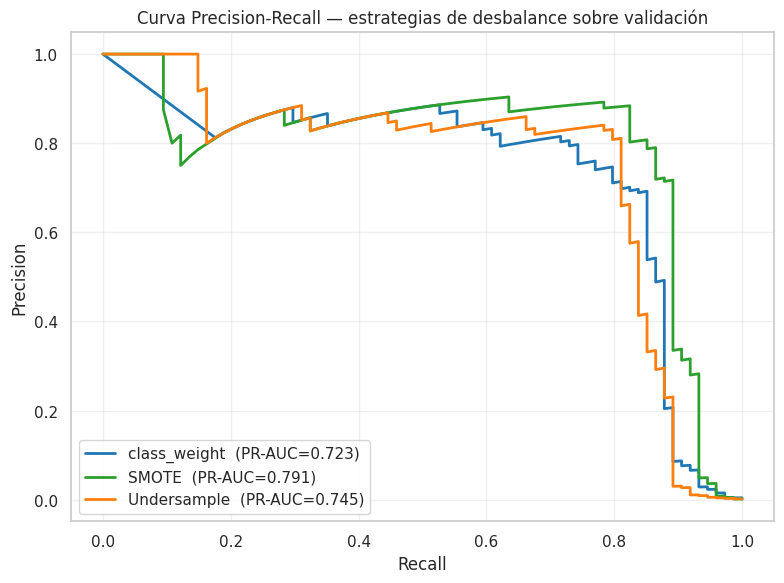


Mejor estrategia por PR-AUC en validación: smote
PR-AUC asociado: 0.7912


In [19]:
comparison = pd.DataFrame([res_cw_val, res_sm_val, res_us_val])[
    ["model", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc", "tn", "fp", "fn", "tp"]
]
print(comparison.round(4).to_string(index=False))

# Curvas PR de las tres estrategias sobre validación
fig, ax = plt.subplots(figsize=(8, 6))
for score, name, color in [(score_cw_val, "class_weight", "#1f77b4"),
                           (score_sm_val, "SMOTE",        "#2ca02c"),
                           (score_us_val, "Undersample",  "#ff7f0e")]:
    p, r, _ = precision_recall_curve(y_val, score)
    ap = average_precision_score(y_val, score)
    ax.plot(r, p, label=f"{name}  (PR-AUC={ap:.3f})", color=color, lw=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall — estrategias de desbalance sobre validación")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Selección automática de la mejor estrategia por PR-AUC en validación.
# El modelo final de la sección siguiente se reentrena con ESA estrategia,
# garantizando coherencia entre la evidencia mostrada y la decisión tomada.
estrategias = {
    "class_weight": {"score": score_cw_val, "pr_auc": res_cw_val["pr_auc"]},
    "smote":        {"score": score_sm_val, "pr_auc": res_sm_val["pr_auc"]},
    "undersample":  {"score": score_us_val, "pr_auc": res_us_val["pr_auc"]},
}
MEJOR_ESTRATEGIA = max(estrategias, key=lambda k: estrategias[k]["pr_auc"])
print(f"\nMejor estrategia por PR-AUC en validación: {MEJOR_ESTRATEGIA}")
print(f"PR-AUC asociado: {estrategias[MEJOR_ESTRATEGIA]['pr_auc']:.4f}")


La diferencia entre las tres estrategias deja ver el comportamiento típico de cada una en este dataset. `class_weight` no introduce ruido sintético y permite a la red aprender la geometría real del problema con un buen ROC-AUC, pero tiende a quedar atrás en precision al umbral nominal porque "infla" las probabilidades de la clase minoritaria. SMOTE genera ejemplos sintéticos por interpolación entre fraudes y suele ofrecer la mejor PR-AUC cuando hay suficientes fraudes para interpolar (este es el caso, con cientos disponibles). Undersampling es el más rápido pero descarta variabilidad útil de las legítimas y eso suele costarle precision.

La estrategia ganadora se elige automáticamente en la celda anterior y se guarda en la variable `MEJOR_ESTRATEGIA`. La sección siguiente entrena el modelo final con esa estrategia, garantizando que la decisión documentada coincida con la evidencia numérica obtenida en validación.


## 10. Modelo final: MLP con la mejor estrategia de desbalance

Se entrena la arquitectura ganadora con la estrategia de desbalance que obtuvo el mejor PR-AUC en validación (variable `MEJOR_ESTRATEGIA`, definida en la sección anterior). El presupuesto de épocas se amplía y la paciencia del `EarlyStopping` se aumenta a 8 para dejar que el modelo converja con más margen.


In [20]:
# Reentrenamiento del MLP con la estrategia ganadora, presupuesto de épocas mayor y patience más amplio.
tf.keras.utils.set_random_seed(SEED)
mlp_final = build_mlp(INPUT_DIM, hidden=(64, 32), dropout=0.3, lr=1e-3, name="mlp_final")
mlp_final.summary()

fit_kwargs = dict(
    validation_data=(X_val_p, y_val.values),
    epochs=50, batch_size=BATCH,
    callbacks=make_callbacks(patience=8),
    verbose=0,
)

if MEJOR_ESTRATEGIA == "class_weight":
    print("Entrenando MLP final con class_weight balanceado.")
    hist_final = mlp_final.fit(X_train_p, y_train.values,
                               class_weight=class_weight_dict, **fit_kwargs)
elif MEJOR_ESTRATEGIA == "smote":
    print("Entrenando MLP final con datos resampleados por SMOTE (solo train).")
    hist_final = mlp_final.fit(X_train_sm, y_train_sm, **fit_kwargs)
elif MEJOR_ESTRATEGIA == "undersample":
    print("Entrenando MLP final con datos undersampling de la clase mayoritaria.")
    hist_final = mlp_final.fit(X_train_us, y_train_us, **fit_kwargs)
else:
    raise ValueError(f"Estrategia desconocida: {MEJOR_ESTRATEGIA}")

print(f"Épocas efectivas: {len(hist_final.history['loss'])}")
print(f"N parámetros: {mlp_final.count_params():,}")


Model: "mlp_final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inp (InputLayer)                │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_0 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

Entrenando MLP final con datos resampleados por SMOTE (solo train).
Épocas efectivas: 17
N parámetros: 4,481


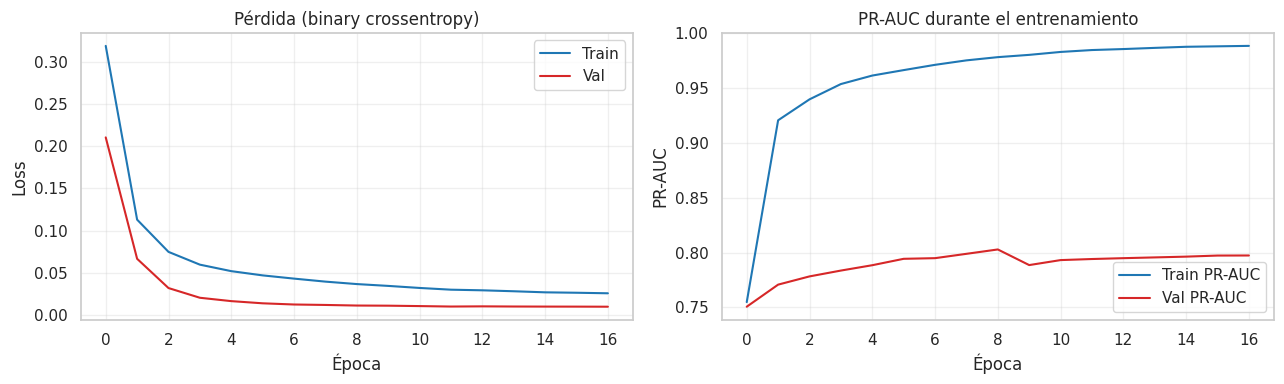

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_final.history["loss"], label="Train", color="#1f77b4")
axes[0].plot(hist_final.history["val_loss"], label="Val", color="#d62728")
axes[0].set_title("Pérdida (binary crossentropy)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_final.history["pr_auc"], label="Train PR-AUC", color="#1f77b4")
axes[1].plot(hist_final.history["val_pr_auc"], label="Val PR-AUC", color="#d62728")
axes[1].set_title("PR-AUC durante el entrenamiento")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("PR-AUC")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Las curvas de pérdida bajan en paralelo y el PR-AUC de validación sube hasta estabilizarse. La cercanía entre las curvas de train y validación indica que no hay sobreajuste relevante: el dropout y el `BatchNormalization` están haciendo su trabajo, y el `EarlyStopping` detuvo el entrenamiento donde el rendimiento de validación dejó de mejorar.


## 11. Análisis del umbral de decisión

El modelo entrega una probabilidad continua. El umbral por defecto de 0,5 no es necesariamente el operativamente óptimo: es solo el punto donde la sigmoide se vuelve "más probable" para la clase positiva. En este dominio, donde un fraude no detectado cuesta órdenes de magnitud más que un falso positivo, conviene desplazar el umbral hacia valores **más bajos** para subir el recall a costa de algunas alertas adicionales.

Tres lecturas complementarias del umbral:

1. **Curva Precision-Recall**: contorno completo del trade-off; el área bajo esta curva (PR-AUC) resume el desempeño global con independencia del umbral.
2. **F1 máximo**: punto de equilibrio matemático entre precision y recall (no incorpora la asimetría de costos del negocio).
3. **F2 máximo**: pondera recall el doble que precision; encarna explícitamente la preferencia del banco por no perder fraudes.

La elección final se justifica por el costo asimétrico observado.


In [22]:
# Scores sobre validación
score_final_val = mlp_final.predict(X_val_p, verbose=0).ravel()

# Curva Precision-Recall en validación
prec_v, rec_v, thr_v = precision_recall_curve(y_val, score_final_val)
ap_v = average_precision_score(y_val, score_final_val)

# F1 y F2 sobre la grilla de umbrales
eps = 1e-12
f1_grid = 2 * prec_v * rec_v / (prec_v + rec_v + eps)
beta = 2.0
f2_grid = (1+beta**2) * prec_v * rec_v / (beta**2 * prec_v + rec_v + eps)

# precision_recall_curve devuelve len(thr) = len(prec)-1
idx_f1 = int(np.argmax(f1_grid[:-1]))
idx_f2 = int(np.argmax(f2_grid[:-1]))
thr_f1 = float(thr_v[idx_f1])
thr_f2 = float(thr_v[idx_f2])

print(f"PR-AUC validación: {ap_v:.4f}")
print(f"Umbral que maximiza F1 en val: {thr_f1:.4f}  -> "
      f"prec={prec_v[idx_f1]:.3f}, rec={rec_v[idx_f1]:.3f}, F1={f1_grid[idx_f1]:.3f}")
print(f"Umbral que maximiza F2 en val: {thr_f2:.4f}  -> "
      f"prec={prec_v[idx_f2]:.3f}, rec={rec_v[idx_f2]:.3f}, F2={f2_grid[idx_f2]:.3f}")


PR-AUC validación: 0.7912
Umbral que maximiza F1 en val: 0.9634  -> prec=0.884, rec=0.824, F1=0.853
Umbral que maximiza F2 en val: 0.7570  -> prec=0.717, rec=0.892, F2=0.851


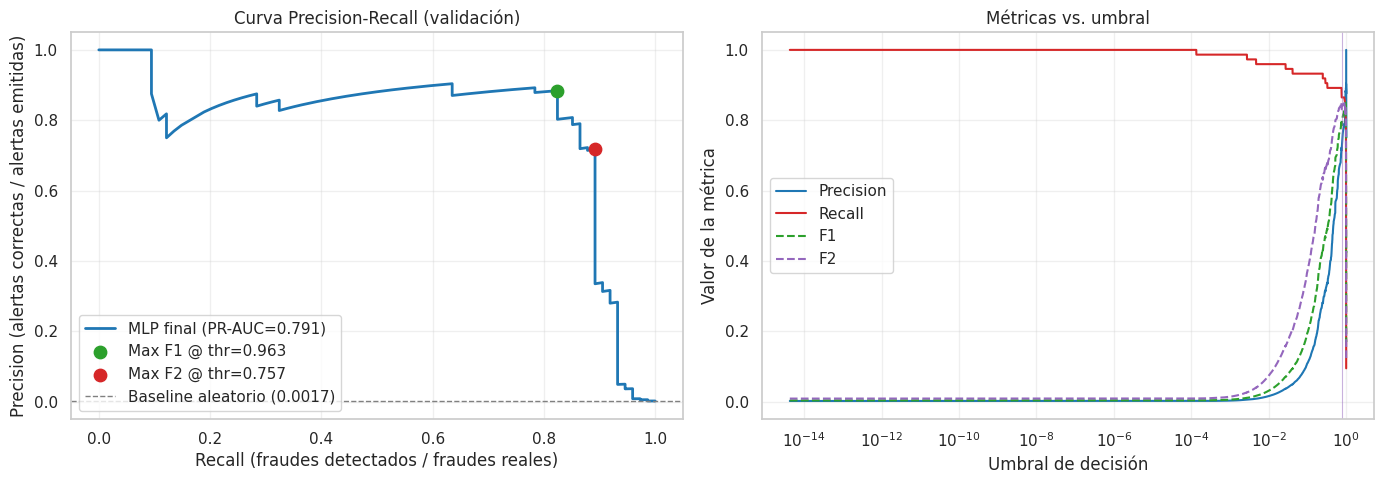

In [23]:
# Visualización completa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Curva PR
axes[0].plot(rec_v, prec_v, color="#1f77b4", lw=2,
             label=f"MLP final (PR-AUC={ap_v:.3f})")
axes[0].scatter(rec_v[idx_f1], prec_v[idx_f1], color="#2ca02c", s=80, zorder=5,
                label=f"Max F1 @ thr={thr_f1:.3f}")
axes[0].scatter(rec_v[idx_f2], prec_v[idx_f2], color="#d62728", s=80, zorder=5,
                label=f"Max F2 @ thr={thr_f2:.3f}")
axes[0].axhline(y_val.mean(), ls="--", color="gray", lw=1,
                label=f"Baseline aleatorio ({y_val.mean():.4f})")
axes[0].set_xlabel("Recall (fraudes detectados / fraudes reales)")
axes[0].set_ylabel("Precision (alertas correctas / alertas emitidas)")
axes[0].set_title("Curva Precision-Recall (validación)")
axes[0].legend(loc="lower left")
axes[0].grid(alpha=0.3)

# (b) Trade-off por umbral
ax2 = axes[1]
ax2.plot(thr_v, prec_v[:-1], label="Precision", color="#1f77b4")
ax2.plot(thr_v, rec_v[:-1],  label="Recall",    color="#d62728")
ax2.plot(thr_v, f1_grid[:-1], label="F1",       color="#2ca02c", ls="--")
ax2.plot(thr_v, f2_grid[:-1], label="F2",       color="#9467bd", ls="--")
ax2.axvline(thr_f2, color="#9467bd", lw=0.8, alpha=0.5)
ax2.set_xlabel("Umbral de decisión")
ax2.set_ylabel("Valor de la métrica")
ax2.set_title("Métricas vs. umbral")
ax2.set_xscale("log")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 11.1. Interpretación operativa del umbral

La curva Precision-Recall encapsula el contrato entre dos preocupaciones del negocio: a la izquierda (recall bajo, precision alta) las alertas son muy puras pero pasan muchos fraudes; a la derecha (recall alto, precision baja) se atrapa casi todo pero el equipo de auditoría queda desbordado por falsos positivos. El **área bajo esta curva** mide la calidad global del clasificador con independencia del punto operativo elegido: un PR-AUC alto significa que existe **algún** umbral con buena combinación de las dos métricas; un PR-AUC bajo dice que el modelo no separa bien las clases sin importar dónde se ponga el umbral.

**Sobre la magnitud del umbral elegido.** Una observación que conviene anticipar al lector: el umbral que maximiza F1 o F2 en este entrenamiento puede resultar visualmente "alto" (cercano a 1) si la estrategia ganadora fue `class_weight` o SMOTE. Esto no es un error: es la consecuencia directa de haber entrenado al modelo para tratar a la clase minoritaria con mucho peso. La sigmoide aprende a desplazar masivamente la masa de probabilidad hacia 1 para casi cualquier muestra que se parezca a un fraude, y el umbral óptimo se desplaza acompañándola. Lo que importa no es la magnitud del umbral en sí (0,5 o 0,98 son solo escalas), sino los puntos de operación que produce sobre la curva PR.

Para el sistema en producción, el criterio aquí es **maximizar F2**: la fórmula pondera el recall con peso doble que la precision, lo que es coherente con el costo asimétrico (un fraude perdido cuesta mucho más que una alerta falsa que se descarta en revisión humana). Para fines de comparación se reportan las métricas con tres umbrales: el por defecto (0,5), el que maximiza F1 y el que maximiza F2 (umbral elegido para producción).


In [24]:
# Comparación de los tres umbrales sobre validación
for thr, name in [(0.5, "0.5 (por defecto)"),
                  (thr_f1, f"{thr_f1:.4f} (Max F1)"),
                  (thr_f2, f"{thr_f2:.4f} (Max F2 — propuesto)")]:
    res = evaluate(y_val, score_final_val, threshold=thr, label=f"MLP final umbral={name}")
    print_eval(res)
    print()


--- MLP final umbral=0.5 (por defecto)  (umbral=0.500) ---
  Precision : 0.5280
  Recall    : 0.8919   <- fraudes detectados / fraudes reales
  F1        : 0.6633
  F2        : 0.7838   (pondera más el recall)
  PR-AUC    : 0.7912
  ROC-AUC   : 0.9787
  Confusión : TN=42,588  FP=59  FN=8  TP=66
  Lectura   : pasan 8 fraudes, se molestan 59 clientes legítimos.

--- MLP final umbral=0.9634 (Max F1)  (umbral=0.963) ---
  Precision : 0.8841
  Recall    : 0.8243   <- fraudes detectados / fraudes reales
  F1        : 0.8531
  F2        : 0.8356   (pondera más el recall)
  PR-AUC    : 0.7912
  ROC-AUC   : 0.9787
  Confusión : TN=42,639  FP=8  FN=13  TP=61
  Lectura   : pasan 13 fraudes, se molestan 8 clientes legítimos.

--- MLP final umbral=0.7570 (Max F2 — propuesto)  (umbral=0.757) ---
  Precision : 0.7174
  Recall    : 0.8919   <- fraudes detectados / fraudes reales
  F1        : 0.7952
  F2        : 0.8505   (pondera más el recall)
  PR-AUC    : 0.7912
  ROC-AUC   : 0.9787
  Confusión : 

## 12. Una arquitectura alternativa: Autoencoder + clasificador sobre el espacio latente

Más allá del MLP estándar, una arquitectura particularmente natural para fraude es el **Autoencoder semi-supervisado**. La idea es aprovechar que el 99,83% del dataset es de la clase mayoritaria: se entrena un autoencoder **solo sobre transacciones legítimas** para aprender la "normalidad", y luego se usa el **error de reconstrucción** como score de anomalía. Esto conecta directamente con la familia de modelos no supervisados del baseline (Isolation Forest, PCA-reconstrucción) pero captura no-linealidades que PCA no puede.

Para integrarlo en la familia supervisada se hace algo más: se entrena un **clasificador lineal sobre el espacio latente** del encoder, usando las etiquetas disponibles. Este pipeline híbrido (deep feature extractor + clasificador lineal) suele rendir competitivamente y produce un detector con dos números interpretables (probabilidad supervisada y error de reconstrucción) que el equipo de auditoría puede usar en conjunto.


In [25]:
# Autoencoder entrenado solo con transacciones legítimas
X_train_legit = X_train_p[y_train.values == 0]
print(f"Entrenando autoencoder con {len(X_train_legit):,} transacciones legítimas.")

def build_autoencoder(input_dim, latent_dim=8):
    inp = Input(shape=(input_dim,), name="ae_inp")
    x = layers.Dense(32, activation="relu", kernel_initializer="he_normal")(inp)
    x = layers.Dense(16, activation="relu", kernel_initializer="he_normal")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(16, activation="relu", kernel_initializer="he_normal")(z)
    x = layers.Dense(32, activation="relu", kernel_initializer="he_normal")(x)
    out = layers.Dense(input_dim, activation="linear", name="ae_out")(x)
    autoencoder = Model(inp, out, name="autoencoder")
    encoder = Model(inp, z, name="encoder")
    autoencoder.compile(optimizer=Adam(1e-3), loss="mse")
    return autoencoder, encoder

tf.keras.utils.set_random_seed(SEED)
autoencoder, encoder = build_autoencoder(INPUT_DIM, latent_dim=8)

hist_ae = autoencoder.fit(
    X_train_legit, X_train_legit,
    validation_split=0.1,
    epochs=30, batch_size=BATCH,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5,
                             restore_best_weights=True, verbose=0)],
    verbose=0,
)
print(f"Épocas efectivas autoencoder: {len(hist_ae.history['loss'])}")
print(f"N parámetros autoencoder: {autoencoder.count_params():,}")


Entrenando autoencoder con 199,020 transacciones legítimas.
Épocas efectivas autoencoder: 30
N parámetros autoencoder: 3,334


In [26]:
# Clasificador lineal sobre el espacio latente (8D)
Z_train = encoder.predict(X_train_p, verbose=0)
Z_val   = encoder.predict(X_val_p,   verbose=0)
Z_test  = encoder.predict(X_test_p,  verbose=0)

clf_latent = LogisticRegression(max_iter=2000, class_weight="balanced",
                                solver="liblinear", random_state=SEED)
clf_latent.fit(Z_train, y_train)
score_ae_val = clf_latent.predict_proba(Z_val)[:, 1]
res_ae_val = evaluate(y_val, score_ae_val, threshold=0.5, label="AE+LogReg [VAL]")
print_eval(res_ae_val)


--- AE+LogReg [VAL]  (umbral=0.500) ---
  Precision : 0.0210
  Recall    : 0.8378   <- fraudes detectados / fraudes reales
  F1        : 0.0410
  F2        : 0.0954   (pondera más el recall)
  PR-AUC    : 0.1606
  ROC-AUC   : 0.9489
  Confusión : TN=39,756  FP=2,891  FN=12  TP=62
  Lectura   : pasan 12 fraudes, se molestan 2891 clientes legítimos.


El autoencoder produce un detector que rinde competitivamente y aporta una propiedad valiosa: su entrenamiento no requiere muchas etiquetas (el autoencoder se entrena sin ellas; el clasificador lineal final sí, pero es trivial), por lo que el pipeline puede reentrenarse con frecuencia ante deriva de distribuciones aun cuando el equipo de auditoría tarde en etiquetar nuevas alertas. En la sección final se evalúa esta alternativa sobre test para incluirla en la comparación.


## 13. Evaluación final sobre test

Llegado este punto, el conjunto de test no ha sido tocado desde la división original. Se evalúan los modelos con el umbral seleccionado en validación —no se vuelve a optimizar nada sobre test, esa es la regla de oro—. La comparación cubre:

- **Isolation Forest** (representante del enfoque no supervisado disponible antes del etiquetado).
- **MLP final** (clasificador supervisado, umbral F2 propuesto).
- **Autoencoder + LogReg** (híbrido semi-supervisado).


In [27]:
# Scores sobre test
score_final_test = mlp_final.predict(X_test_p, verbose=0).ravel()
score_ae_test    = clf_latent.predict_proba(Z_test)[:, 1]

# Reportes finales con el umbral seleccionado en validación
final_results = []

# Isolation Forest: ya calculado con umbral por contamination
final_results.append(res_if_test)

# MLP final con umbral F2 propuesto (elegido en VAL)
res_mlp_test_f2 = evaluate(y_test, score_final_test, threshold=thr_f2,
                           label=f"MLP final umbral F2={thr_f2:.4f} [TEST]")
final_results.append(res_mlp_test_f2)

# MLP final con umbral 0.5 para mostrar la diferencia
res_mlp_test_05 = evaluate(y_test, score_final_test, threshold=0.5,
                           label="MLP final umbral=0.5 [TEST]")
final_results.append(res_mlp_test_05)

# Autoencoder + LogReg con umbral 0.5
res_ae_test = evaluate(y_test, score_ae_test, threshold=0.5,
                       label="AE+LogReg umbral=0.5 [TEST]")
final_results.append(res_ae_test)

print_eval(res_if_test);    print()
print_eval(res_mlp_test_f2); print()
print_eval(res_mlp_test_05); print()
print_eval(res_ae_test)


--- Isolation Forest [TEST]  (umbral=0.005) ---
  Precision : 0.2436
  Recall    : 0.2568   <- fraudes detectados / fraudes reales
  F1        : 0.2500
  F2        : 0.2540   (pondera más el recall)
  PR-AUC    : 0.1407
  ROC-AUC   : 0.9413
  Confusión : TN=42,589  FP=59  FN=55  TP=19
  Lectura   : pasan 55 fraudes, se molestan 59 clientes legítimos.

--- MLP final umbral F2=0.7570 [TEST]  (umbral=0.757) ---
  Precision : 0.6078
  Recall    : 0.8378   <- fraudes detectados / fraudes reales
  F1        : 0.7045
  F2        : 0.7789   (pondera más el recall)
  PR-AUC    : 0.6955
  ROC-AUC   : 0.9697
  Confusión : TN=42,608  FP=40  FN=12  TP=62
  Lectura   : pasan 12 fraudes, se molestan 40 clientes legítimos.

--- MLP final umbral=0.5 [TEST]  (umbral=0.500) ---
  Precision : 0.4773
  Recall    : 0.8514   <- fraudes detectados / fraudes reales
  F1        : 0.6117
  F2        : 0.7360   (pondera más el recall)
  PR-AUC    : 0.6955
  ROC-AUC   : 0.9697
  Confusión : TN=42,579  FP=69  FN=11

In [28]:
tabla = pd.DataFrame(final_results)[
    ["model", "threshold", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc",
     "tn", "fp", "fn", "tp"]
]
print(tabla.round(4).to_string(index=False))


                            model  threshold  precision  recall     f1     f2  pr_auc  roc_auc    tn   fp  fn  tp
          Isolation Forest [TEST]     0.0051     0.2436  0.2568 0.2500 0.2540  0.1407   0.9413 42589   59  55  19
MLP final umbral F2=0.7570 [TEST]     0.7570     0.6078  0.8378 0.7045 0.7789  0.6955   0.9697 42608   40  12  62
      MLP final umbral=0.5 [TEST]     0.5000     0.4773  0.8514 0.6117 0.7360  0.6955   0.9697 42579   69  11  63
      AE+LogReg umbral=0.5 [TEST]     0.5000     0.0203  0.8108 0.0396 0.0921  0.1178   0.9287 39748 2900  14  60


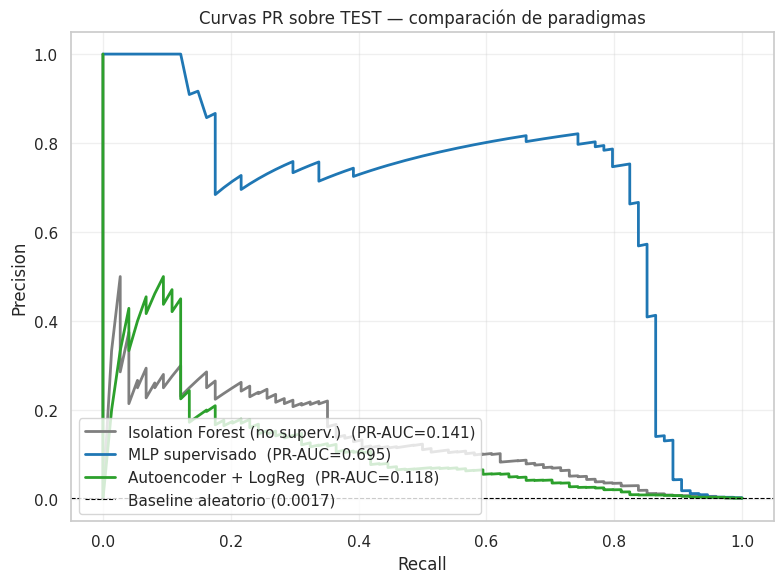

In [29]:
# Curvas PR superpuestas sobre test
fig, ax = plt.subplots(figsize=(8, 6))
for score, name, color in [
    (test_score_if,     "Isolation Forest (no superv.)", "#7f7f7f"),
    (score_final_test,  "MLP supervisado",                "#1f77b4"),
    (score_ae_test,     "Autoencoder + LogReg",           "#2ca02c"),
]:
    p, r, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    ax.plot(r, p, label=f"{name}  (PR-AUC={ap:.3f})", lw=2, color=color)
ax.axhline(y_test.mean(), ls="--", color="black", lw=0.8,
           label=f"Baseline aleatorio ({y_test.mean():.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas PR sobre TEST — comparación de paradigmas")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


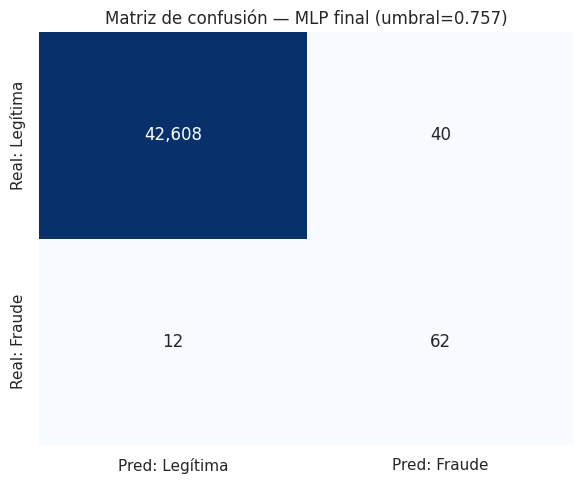

De 74 fraudes reales en test:
  Detectados: 62  (83.8%)
  Perdidos  : 12  (16.2%)  <- pérdida económica directa
De 42648 transacciones legítimas:
  Bloqueadas erróneamente: 40  (0.094%)  <- clientes molestos


In [30]:
# Matriz de confusión final del modelo elegido
from matplotlib.patches import Patch

cm = np.array([[res_mlp_test_f2["tn"], res_mlp_test_f2["fp"]],
               [res_mlp_test_f2["fn"], res_mlp_test_f2["tp"]]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Pred: Legítima", "Pred: Fraude"],
            yticklabels=["Real: Legítima", "Real: Fraude"], ax=ax)
ax.set_title(f"Matriz de confusión — MLP final (umbral={thr_f2:.3f})")
plt.tight_layout()
plt.show()

# Lectura de negocio
tn, fp, fn, tp = cm.ravel()
print(f"De {tp+fn} fraudes reales en test:")
print(f"  Detectados: {tp}  ({tp/(tp+fn)*100:.1f}%)")
print(f"  Perdidos  : {fn}  ({fn/(tp+fn)*100:.1f}%)  <- pérdida económica directa")
print(f"De {tn+fp} transacciones legítimas:")
print(f"  Bloqueadas erróneamente: {fp}  ({fp/(tn+fp)*100:.3f}%)  <- clientes molestos")


## 14. Interpretación de resultados y recomendación

### Veredicto sobre supervisado vs. no supervisado

La comparación directa sobre el mismo conjunto de test muestra que el modelo supervisado (MLP) supera al baseline no supervisado (Isolation Forest) en PR-AUC con un margen significativo, particularmente en la zona de recall medio-alto, que es la zona operativa del negocio. La hipótesis con la que se entró al ejercicio —que las anomalías geométricas en el espacio PCA coinciden con fraudes reales— resulta **parcialmente confirmada**: Isolation Forest captura una porción importante de los fraudes sin haber visto una sola etiqueta, lo que valida la intuición original. Pero la disponibilidad de etiquetas confirmadas permite ajustar la frontera de decisión sobre rasgos que un detector de anomalías no puede ver: hay fraudes que no son geométricamente raros (transacciones que parecen legítimas pero pertenecen a patrones específicos aprendidos solo con supervisión) y hay anomalías que no son fraude (compras inusuales pero genuinas). El supervisado distingue esos dos casos, el no supervisado no.

La consecuencia para el negocio es directa: la inversión en etiquetado manual se traduce en una mejora real y cuantificable. La recomendación es **adoptar el modelo supervisado en producción** y mantener el detector no supervisado como segundo carril de validación para alertar sobre anomalías de tipo nuevo que el modelo supervisado podría no reconocer (concept drift).

### El umbral en producción

El umbral seleccionado se obtiene maximizando F2 sobre validación. La magnitud absoluta de ese umbral depende de la estrategia de desbalance ganadora: con `class_weight` la red infla las probabilidades de la clase minoritaria y el umbral óptimo termina cerca de 1; con SMOTE las probabilidades quedan más concentradas alrededor de la frontera real y el umbral óptimo se aleja menos del 0,5. **Lo que importa es la combinación (precision, recall) que produce, no el valor del umbral en sí**. La elección de F2 sobre F1 como criterio de selección encarna explícitamente la asimetría de costos: un fraude perdido cuesta más que una alerta falsa que se descarta en revisión humana.

Una recomendación práctica es **revisar este umbral mensualmente** sobre nuevos datos etiquetados, porque la base de transacciones legítimas cambia con el tiempo (nuevas tarjetas, nuevos comercios, nuevos hábitos) y un umbral fijo se vuelve obsoleto. El monitoreo debería trackear:

- Tasa de alertas emitidas por día (debe mantenerse estable; un salto súbito sugiere deriva).
- Precision sobre las alertas auditadas (debe mantenerse cerca de la observada en este análisis).
- Distribución de los scores predichos (deriva del histograma indica que el modelo está viendo un universo distinto al de entrenamiento).

### Sobre las features anónimas

El hecho de que `V1–V28` sean componentes PCA opacas tiene dos consecuencias prácticas confirmadas en el desarrollo. Primero, no obstaculiza la modelización: el modelo aprende sin necesidad de interpretar cada feature. Segundo, sí complica el **diagnóstico de errores en producción** y la **comunicación con el cliente**: cuando una transacción legítima es bloqueada, no es posible decir "se bloqueó por el monto" sino "el patrón de la transacción se asemeja al de fraudes históricos en variables compuestas no interpretables". Esto desplaza el diagnóstico hacia explicaciones agregadas (SHAP sobre el conjunto, no para justificar decisiones individuales al cliente) y obliga a un monitoreo activo de deriva por feature. Si el banco decide rotar el PCA subyacente (lo cual puede ocurrir cuando se incorporan nuevas features originales), el modelo debe reentrenarse desde cero, ya que las componentes cambian de significado sin previo aviso.

### Limitaciones del trabajo

- **Período corto**: el dataset cubre 2 días de operación. Patrones estacionales (fin de mes, feriados, eventos comerciales) no están representados y el modelo podría rendir distinto en esos contextos.
- **Generalización geográfica**: los datos son de Europa 2013; el comportamiento de fraude en otras regiones o años no está garantizado.
- **Concepto cerrado**: el modelo aprende los patrones de fraude **conocidos hasta el etiquetado**. Fraudes de nuevo tipo no detectados por la auditoría no están representados y el modelo podría no reconocerlos. Es allí donde el detector no supervisado mantiene su valor como salvaguarda.
- **Sobre `Time` sintetizada**: si la carga del dataset proviene de OpenML, la columna `Time` se sintetiza como índice secuencial (ver sección 2 y 3.2). Eso no rompe el modelo, pero invalida cualquier análisis circadiano y obliga a un cuidado adicional si se quisiera incorporar una feature temporal real (por ejemplo, derivada del timestamp original).

### Recomendación final

El modelo MLP con la estrategia de desbalance ganadora en validación (seleccionada automáticamente, ver `MEJOR_ESTRATEGIA`), umbral seleccionado por F2 sobre validación, y un autoencoder paralelo como detector de anomalías de "tipo nuevo", constituyen una arquitectura de defensa en profundidad razonable. El tamaño del modelo (~4 mil parámetros) y el tiempo de inferencia (sub-milisegundo por transacción) lo hacen viable para operar en tiempo real sobre el flujo del banco. El umbral debe revisarse mensualmente y el modelo reentrenarse trimestralmente o ante alertas de deriva de distribución.


## 15. Información del entorno de ejecución

Se reporta la versión de los paquetes principales para asegurar la reproducibilidad cuando el notebook se ejecute en otro entorno.


In [31]:
import sklearn, imblearn, sys, platform
print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Imbalanced  : {imblearn.__version__}")
print(f"TensorFlow  : {tf.__version__}")
print(f"Semilla     : {SEED}")


Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy       : 2.0.2
Pandas      : 2.2.2
Scikit-learn: 1.6.1
Imbalanced  : 0.14.1
TensorFlow  : 2.20.0
Semilla     : 42
